# Data Analysis Project Phase 3: Data Analysis and Visualization
**Name:** Austin Dachel

In this step, we connect to the SQLite database created in Phase 2 and load the relevant crash data into a Pandas DataFrame. This allows us to perform data cleaning, statistical analysis, and visualization using Python data science tools.

In [1]:
import pandas as pd
import sqlite3

DB_FILE = "ColoradoMotoFatalities.sqlite"

conn = sqlite3.connect(DB_FILE)

query = """
SELECT
    c.crash_id,
    c.year,
    c.crash_date,
    c.county_name,
    c.fatals,
    c.persons,
    c.total_vehicles,
    v.hour
FROM moto_crashes c
LEFT JOIN moto_vehicles v
ON c.crash_id = v.crash_id
"""

df = pd.read_sql_query(query, conn)

conn.close()

# Clean time column
df["hour"] = pd.to_numeric(df["hour"], errors="coerce")
df_time = df[["crash_id", "year", "hour"]].drop_duplicates(subset=["crash_id"]).copy()
df_time = df_time.dropna(subset=["hour"])

# Create day/night classification
df["time_of_day"] = df["hour"].apply(
    lambda h: "Night" if pd.notnull(h) and (h < 6 or h >= 18) else "Day"
)

# Remove duplicate crashes (vehicle table may contain multiple vehicles per crash)
df = df.drop_duplicates(subset=["crash_id"])

# Convert crash date
df["crash_date"] = pd.to_datetime(df["crash_date"], errors="coerce")

# Extract month
df["month"] = df["crash_date"].dt.month

print("Analysis dataset created and saved.")

print("Dataset shape:", df.shape)

df.head()

Analysis dataset created and saved.
Dataset shape: (639, 10)


,crash_id,year,crash_date,county_name,fatals,persons,total_vehicles,hour,time_of_day,month
0,2019-80032,2019,2019-02-03,DENVER (31),2,3,2,21,Night,2
1,2019-80044,2019,2019-02-20,ADAMS (1),1,1,1,13,Day,2
2,2019-80054,2019,2019-03-01,EL PASO (41),1,1,1,18,Night,3
3,2019-80063,2019,2019-03-18,PUEBLO (101),1,2,2,20,Night,3
4,2019-80085,2019,2019-03-26,JEFFERSON (59),1,1,1,7,Day,3


#### Dataset Overview
Before performing analysis, we examine the dataset structure and basic descriptive statistics.

In [2]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 639 entries, 0 to 659
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   crash_id        639 non-null    object        
 1   year            639 non-null    int64         
 2   crash_date      639 non-null    datetime64[ns]
 3   county_name     639 non-null    object        
 4   fatals          639 non-null    int64         
 5   persons         639 non-null    int64         
 6   total_vehicles  639 non-null    int64         
 7   hour            639 non-null    int64         
 8   time_of_day     639 non-null    object        
 9   month           639 non-null    int32         
dtypes: datetime64[ns](1), int32(1), int64(5), object(3)
memory usage: 52.4+ KB


crash_id          0
year              0
crash_date        0
county_name       0
fatals            0
persons           0
total_vehicles    0
hour              0
time_of_day       0
month             0
dtype: int64

## Data Cleaning

Before performing analysis, the dataset is checked for potential issues including:

- Missing values
- Incorrect data types
- Invalid or out-of-range values

The crash-level dataset and crash-time dataset are cleaned separately to ensure
that the data used in analysis is accurate and consistent.

In [3]:
# Ensure crash_date is datetime
df["crash_date"] = pd.to_datetime(df["crash_date"], errors="coerce")

# Ensure hour column is numeric
df["hour"] = pd.to_numeric(df["hour"], errors="coerce")

# Replace missing county names
df["county_name"] = df["county_name"].fillna("Unknown")

# Ensure valid hour values
df = df[(df["hour"].isna()) | ((df["hour"] >= 0) & (df["hour"] <= 23))]

# Recalculate month in case CSV was edited
df["month"] = df["crash_date"].dt.month

print("Data cleaning complete.")

Data cleaning complete.


In [4]:
df.to_csv("cleaned_motorcycle_crashes_CO.csv", index=False)

print("Clean dataset saved.")

Clean dataset saved.


## Visualization Configuration

This cell defines global visualization settings for the notebook.  
Centralizing plot styling ensures that all figures share a consistent appearance, improving readability and making the analysis easier to interpret.

In [5]:
import matplotlib.pyplot as plt

# Configure global plotting parameters for consistent visualization styling
def set_plot_style():
    plt.style.use("seaborn-v0_8-dark-palette")

    plt.rcParams.update({
        "figure.figsize": (10,6),
        "font.size": 12,

        "axes.grid": True,
        "axes.axisbelow": True,
        "axes.spines.top": False,
        "axes.spines.right": False,

        "axes.labelweight": "bold",
        "axes.titleweight": "bold",

        "grid.alpha": 0.5,
        "grid.linewidth": 0.8
    })

set_plot_style()
print("Plot style set.")

Plot style set.


## Analysis 1 – Monthly Crash Distribution
This analysis identifies which months have the highest number of fatal motorcycle crashes in Colorado between 2019 and 2023.

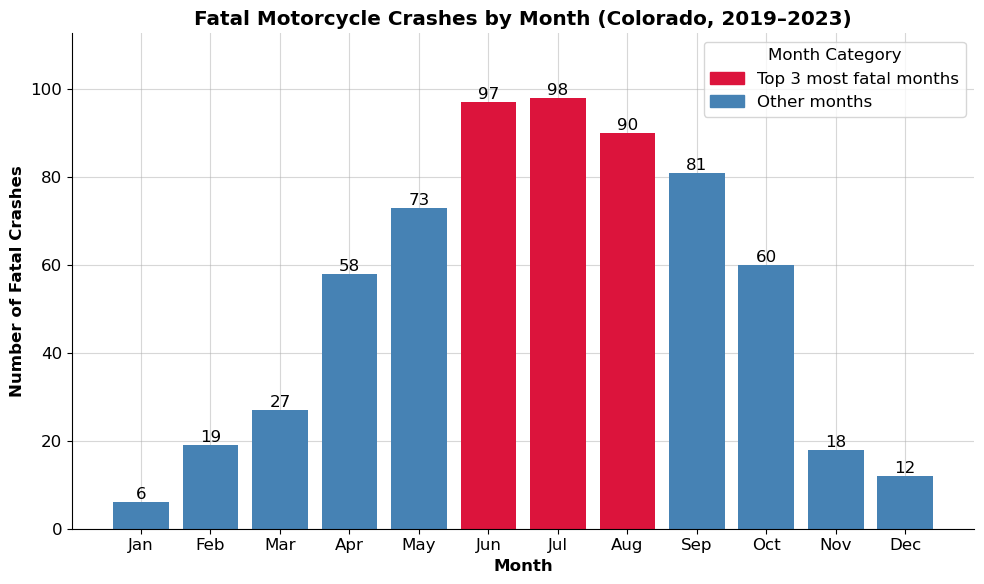

In [6]:
import calendar
import matplotlib.patches as mpatches

monthly_counts = df.groupby("month").size().sort_index()
month_labels = [calendar.month_abbr[m] for m in monthly_counts.index]

# Top 3 months by crash count
top_months = monthly_counts.nlargest(3).index

# Colors (highlight top months)
colors = ["crimson" if m in top_months else "steelblue" for m in monthly_counts.index]

plt.figure()
bars = plt.bar(month_labels, monthly_counts.values, color=colors)

plt.title("Fatal Motorcycle Crashes by Month (Colorado, 2019–2023)")
plt.xlabel("Month")
plt.ylabel("Number of Fatal Crashes")

# Value labels on bars
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f"{int(h)}", ha="center", va="bottom")

plt.ylim(0, max(monthly_counts.values) * 1.15)

# Legend (custom handles)
highlight_patch = mpatches.Patch(color="crimson", label="Top 3 most fatal months")
normal_patch = mpatches.Patch(color="steelblue", label="Other months")
plt.legend(handles=[highlight_patch, normal_patch], title="Month Category")

plt.tight_layout()
plt.show()

## Analysis 2 - Fatal Motorcycle Crashes by Month and Year

This heatmap visualizes the distribution of fatal motorcycle crashes across months and years.  
Darker colors represent higher crash counts. Each cell also displays the exact number of fatal crashes.

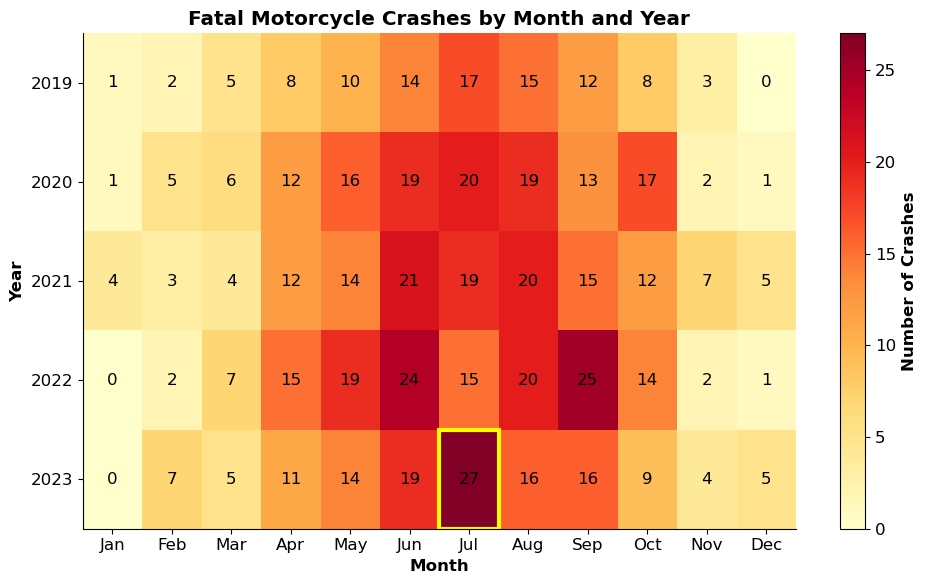

In [7]:
# Import numpy for extra data clarity
import numpy as np
# Create crash counts by year and month
heatmap_data = (
    df.groupby(["year", "month"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

plt.figure(figsize=(10,6))

plt.grid(False)

im = plt.imshow(heatmap_data, cmap="YlOrRd", aspect="auto")

plt.colorbar(im, label="Number of Crashes")

plt.title("Fatal Motorcycle Crashes by Month and Year")
plt.xlabel("Month")
plt.ylabel("Year")

# Month labels
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

plt.xticks(range(12), month_labels)

# Year labels
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

# Add crash counts inside cells
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]

        plt.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            color="black"
        )

# Identify highest crash cell
max_value = heatmap_data.values.max()
max_pos = np.where(heatmap_data.values == max_value)

# Highlight the highest crash cell
for y, x in zip(max_pos[0], max_pos[1]):
    plt.gca().add_patch(
        plt.Rectangle(
            (x - 0.5, y - 0.5),
            1,
            1,
            fill=False,
            edgecolor="#FFFC00",
            linewidth=3
        )
    )

plt.tight_layout()
plt.show()

## Analysis 3 - Fatal crashes during the day vs night
This shows the relationship between fatal motorcycle crashes per year and if they happened during the day or at night.
Daytime is defined from 6:00 A.M. til 6:00 P.M.

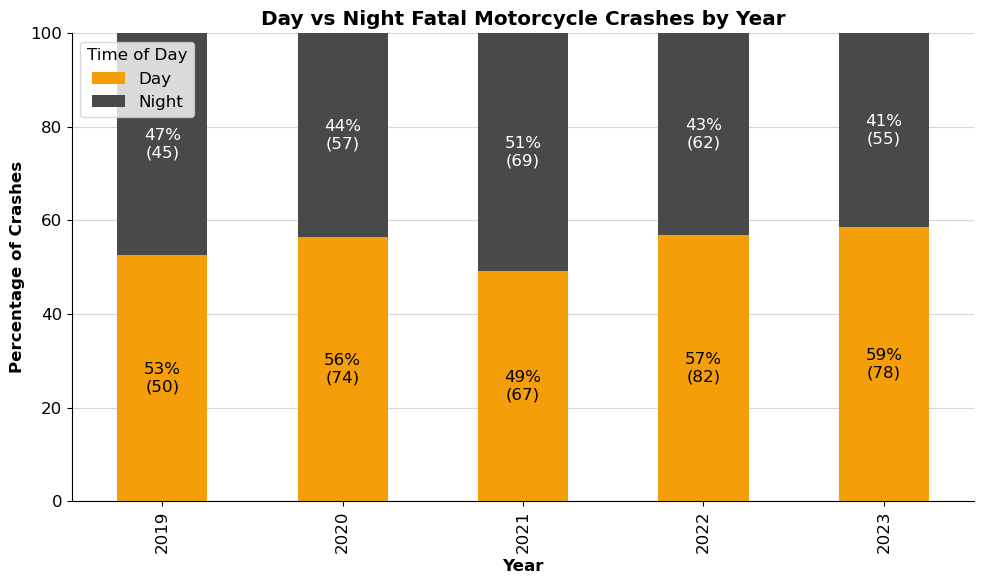

In [8]:
# Create day/night classification
df_time["time_of_day"] = df_time["hour"].apply(
    lambda h: "Night" if (h < 6 or h >= 18) else "Day"
)

# Crash counts
day_night_counts = (
    df_time.groupby(["year", "time_of_day"])
           .size()
           .unstack(fill_value=0)
           .sort_index()
)

# Ensure consistent order
day_night_counts = day_night_counts[["Day", "Night"]]

# Convert to percentages
day_night_pct = day_night_counts.div(day_night_counts.sum(axis=1), axis=0) * 100

# Plot stacked bar
ax = day_night_pct.plot(
    kind="bar",
    stacked=True,
    color=["#F49F0A", "#48494B"]
)

ax.set_title("Day vs Night Fatal Motorcycle Crashes by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Percentage of Crashes")
ax.set_ylim(0, 100)

ax.legend(title="Time of Day")

# Add percentage + raw count labels
for i, year in enumerate(day_night_pct.index):
    cumulative = 0
    
    for category in ["Day", "Night"]:
        pct = day_night_pct.loc[year, category]
        count = day_night_counts.loc[year, category]

        if pct > 5:  # avoid clutter on tiny segments
            ax.text(
                i,
                cumulative + pct/2,
                f"{pct:.0f}%\n({count})",
                ha="center",
                va="center",
                color="white" if category == "Night" else "black"
            )
        
        cumulative += pct

plt.tight_layout()
plt.show()

## Analysis 4 – Counties with the Highest Fatal Motorcycle Crashes
This analysis identifies the counties with the highest number of fatal motorcycle crashes.

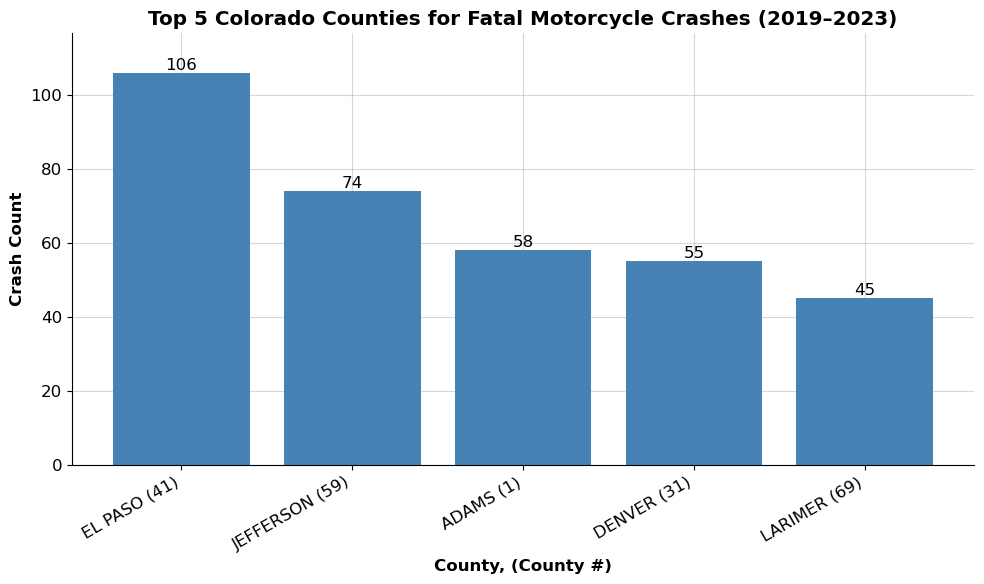

In [9]:
top_counties = df["county_name"].value_counts().head(5)

plt.figure()

bars = plt.bar(top_counties.index, 
               top_counties.values,
               color="steelblue"
              )

plt.title("Top 5 Colorado Counties for Fatal Motorcycle Crashes (2019–2023)")
plt.xlabel("County, (County #)")
plt.ylabel("Crash Count")
plt.xticks(rotation=30, ha="right")

# Add crash counts above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(top_counties.values) * 1.1)
plt.tight_layout()
plt.show()

## Analysis 5 - Fatal Motorcycle Crashes vs Total Fatalities
This analysis shows that there can be multiple fatalities per recorded fatal crash.

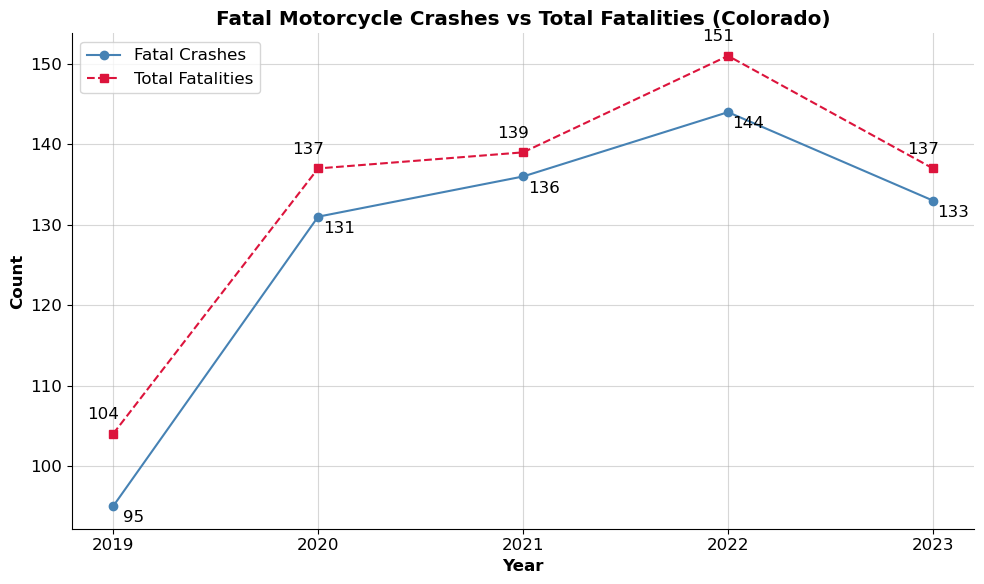

In [10]:
# Calculate yearly crash counts
yearly_crashes = df.groupby("year").size()

# Calculate yearly fatalities
yearly_fatals = df.groupby("year")["fatals"].sum()

plt.figure()

# Plot crashes
plt.plot(
    yearly_crashes.index,
    yearly_crashes.values,
    marker="o",
    label="Fatal Crashes",
    color="steelblue"
)

# Plot fatalities
plt.plot(
    yearly_fatals.index,
    yearly_fatals.values,
    marker="s",
    linestyle="--",
    label="Total Fatalities",
    color="crimson"
)

plt.title("Fatal Motorcycle Crashes vs Total Fatalities (Colorado)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(yearly_crashes.index)

# Add labels for crashes
for x, y in zip(yearly_crashes.index, yearly_crashes.values):
    plt.text(x + 0.1, y - 2, str(y), ha="center")

# Add labels for fatalities
for x, y in zip(yearly_fatals.index, yearly_fatals.values):
    plt.text(x - 0.05, y + 1.8, str(y), ha="center")

plt.legend()

plt.tight_layout()
plt.show()